# A5: Optimization Human Preference & LLM-as-a-Judge

Name: Subhajit Ghosh

In [ ]:
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import gc
import random
import warnings
import torch
import pandas as pd
import matplotlib.pyplot as plt
from openai import OpenAI  # groq uses openai-compatible API
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from trl.trainer.dpo_config import DPOConfig  # import from internal path (not exported in trl 0.8.6)
from trl import DPOTrainer
from peft import LoraConfig, get_peft_model


# groq key - get one free at console.groq.com
GROQ_API_KEY = "GROQ_API_KEY"

client = OpenAI(
    api_key=GROQ_API_KEY,
    base_url="https://api.groq.com/openai/v1",
)

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

In [67]:
# check what device we have - on M2 mac we use MPS
if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"Using CUDA: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    DEVICE = "mps"
    print("Using Apple MPS (Metal)")
else:
    DEVICE = "cpu"
    print("Using CPU")

Using Apple MPS (Metal)


# Task 1: Dataset Preparation (0.5 point)
Loading the truthy-dpo dataset. It has prompt, chosen (correct answer) and rejected (hallucinated answer) columns.

In [68]:
dataset_name = "jondurbin/truthy-dpo-v0.1"
train_dataset = load_dataset(dataset_name, split="train")
print(f"Loaded {len(train_dataset)} samples")
print(f"Columns: {train_dataset.column_names}")

Loaded 1016 samples
Columns: ['id', 'source', 'system', 'prompt', 'chosen', 'rejected']


In [69]:
# lets look at one sample to understand the data
sample = train_dataset[0]
print("PROMPT:")
print(sample["prompt"][:400])
print("\nCHOSEN (factual):")
print(str(sample["chosen"])[:400])
print("\nREJECTED (hallucinated):")
print(str(sample["rejected"])[:400])

PROMPT:
What's the nearest national park to you?

CHOSEN (factual):
As an AI, I don't have a physical location, so I can't provide the distance to the nearest national park.

REJECTED (hallucinated):
I don't have access to the user's location, so I can't determine the nearest national park.


# Task 2: Training with DPOTrainer (2 points)
Using LoRA + DPO to finetune Qwen2.5-1.5B-Instruct. On M2 Mac we load the model in float32 (MPS doesn't fully support float16 for all ops) and use LoRA adapters so we only train a small fraction of the parameters.

In [70]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

# Qwen2.5 has bos_token_id=None which breaks DPOTrainer's tokenize_row
if tokenizer.bos_token_id is None:
    tokenizer.bos_token_id = tokenizer.eos_token_id

# load model - no quantization on Mac, M2 has enough unified memory for 1.5B in fp32
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float32,
    trust_remote_code=True,
)
model = model.to(DEVICE)
print(f"Model loaded on {DEVICE}")

Model loaded on mps


In [71]:
# setup LoRA - target attention layers for parameter-efficient finetuning
model.gradient_checkpointing_enable()
model.enable_input_require_grads()  # needed for gradient checkpointing with LoRA

peft_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()  # should be around 0.14% trainable

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


## Experiment 1 - Baseline
Starting with beta=0.1 and lr=5e-5 as the baseline config. Beta controls how strongly DPO pushes the model to prefer chosen over rejected responses. Using a higher lr because with PEFT ref_model=None, the policy starts identical to the reference so we need stronger updates to see movement.

In [72]:
training_args_1 = DPOConfig(
    output_dir="./dpo_results_exp1",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,  # smaller accumulation = more frequent updates
    learning_rate=5e-5,  # much higher lr for LoRA DPO
    num_train_epochs=1,
    logging_steps=1,
    max_steps=50,
    beta=0.1,
    max_length=256,
    max_prompt_length=128,
    gradient_checkpointing=True,
    report_to="none",
    remove_unused_columns=False,
    optim="adamw_torch",
    fp16=False,
    dataloader_pin_memory=False,
)

trainer_1 = DPOTrainer(
    model=model,
    ref_model=None,
    args=training_args_1,
    train_dataset=train_dataset,
    tokenizer=tokenizer,
)

print("Starting training - Experiment 1")
result_1 = trainer_1.train()
print(f"Done! Loss: {result_1.training_loss:.4f}")

max_steps is given, it will override any value given in num_train_epochs


Starting training - Experiment 1


  2%|▏         | 1/50 [00:11<09:14, 11.31s/it]

{'loss': 0.6931, 'grad_norm': 2995.507568359375, 'learning_rate': 4.9e-05, 'rewards/chosen': 0.0, 'rewards/rejected': 0.0, 'rewards/accuracies': 0.0, 'rewards/margins': 0.0, 'logps/rejected': -106.74109649658203, 'logps/chosen': -128.68515014648438, 'logits/rejected': -1.1351662874221802, 'logits/chosen': -0.09301099181175232, 'epoch': 0.0}


  4%|▍         | 2/50 [00:19<07:27,  9.32s/it]

...

{'loss': 0.6025, 'grad_norm': 4.081005573272705, 'learning_rate': 1.0000000000000002e-06, 'rewards/chosen': 0.07614956796169281, 'rewards/rejected': -0.11596355587244034, 'rewards/accuracies': 1.0, 'rewards/margins': 0.19211313128471375, 'logps/rejected': -140.460693359375, 'logps/chosen': -156.54481506347656, 'logits/rejected': -0.671972393989563, 'logits/chosen': -0.13368502259254456, 'epoch': 0.19}


100%|██████████| 50/50 [46:02<00:00, 22.80s/it]

{'loss': 0.5836, 'grad_norm': 3.628607749938965, 'learning_rate': 0.0, 'rewards/chosen': 0.060074612498283386, 'rewards/rejected': -0.17546311020851135, 'rewards/accuracies': 1.0, 'rewards/margins': 0.23553772270679474, 'logps/rejected': -107.84869384765625, 'logps/chosen': -140.66796875, 'logits/rejected': -0.4091496467590332, 'logits/chosen': -0.07874990999698639, 'epoch': 0.2}


100%|██████████| 50/50 [46:04<00:00, 55.29s/it]

{'train_runtime': 2764.6262, 'train_samples_per_second': 0.072, 'train_steps_per_second': 0.018, 'train_loss': 0.6511046016216278, 'epoch': 0.2}
Done! Loss: 0.6511


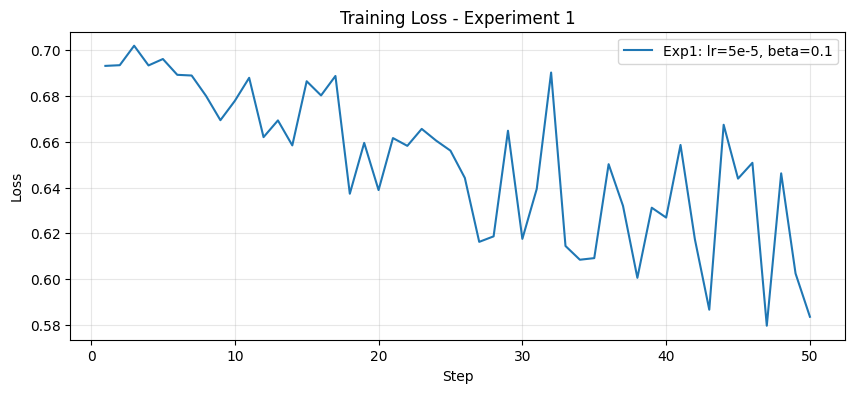

In [73]:
# grab the loss history for plotting later
log1 = trainer_1.state.log_history
steps_1 = [x["step"] for x in log1 if "loss" in x]
loss_1 = [x["loss"] for x in log1 if "loss" in x]

plt.figure(figsize=(10, 4))
plt.plot(steps_1, loss_1, label="Exp1: lr=5e-5, beta=0.1")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training Loss - Experiment 1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Experiment 2 - Higher beta and learning rate
Now trying beta=0.3 (stronger preference signal) and lr=1e-4 (faster updates). Need to reload the model fresh so it's a fair comparison.

In [74]:
# free up memory from exp1
del trainer_1
del model
gc.collect()
torch.mps.empty_cache() if DEVICE == "mps" else None

# reload from scratch
model2 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float32,
    trust_remote_code=True,
)
model2 = model2.to(DEVICE)
model2.gradient_checkpointing_enable()
model2.enable_input_require_grads()
model2 = get_peft_model(model2, peft_config)
model2.print_trainable_parameters()

training_args_2 = DPOConfig(
    output_dir="./dpo_results_exp2",
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    learning_rate=1e-4,   # 2x baseline
    num_train_epochs=1,
    logging_steps=1,
    max_steps=50,
    beta=0.3,             # 3x baseline - stronger preference push
    max_length=256,
    max_prompt_length=128,
    gradient_checkpointing=True,
    report_to="none",
    remove_unused_columns=False,
    optim="adamw_torch",
    fp16=False,
    dataloader_pin_memory=False,
)

trainer_2 = DPOTrainer(
    model=model2,
    ref_model=None,
    args=training_args_2,
    train_dataset=train_dataset,
    tokenizer=tokenizer,
)

print("Starting training - Experiment 2")
result_2 = trainer_2.train()
print(f"Done! Loss: {result_2.training_loss:.4f}")

trainable params: 2,179,072 || all params: 1,545,893,376 || trainable%: 0.1410


max_steps is given, it will override any value given in num_train_epochs


Starting training - Experiment 2


  2%|▏         | 1/50 [01:11<58:15, 71.33s/it]

{'loss': 0.6931, 'grad_norm': 6648.83056640625, 'learning_rate': 9.8e-05, 'rewards/chosen': 0.0, 'rewards/rejected': 0.0, 'rewards/accuracies': 0.0, 'rewards/margins': 0.0, 'logps/rejected': -106.74109649658203, 'logps/chosen': -128.68515014648438, 'logits/rejected': -1.1351662874221802, 'logits/chosen': -0.09301099181175232, 'epoch': 0.0}


...

{'loss': 0.2577, 'grad_norm': 9824.6953125, 'learning_rate': 2.0000000000000003e-06, 'rewards/chosen': 0.429726243019104, 'rewards/rejected': -0.9998354315757751, 'rewards/accuracies': 1.0, 'rewards/margins': 1.4295616149902344, 'logps/rejected': -142.6338348388672, 'logps/chosen': -155.87388610839844, 'logits/rejected': -0.47087362408638, 'logits/chosen': 0.11985287815332413, 'epoch': 0.19}


100%|██████████| 50/50 [1:10:49<00:00, 17.43s/it]

{'loss': 0.2933, 'grad_norm': 6.417740345001221, 'learning_rate': 0.0, 'rewards/chosen': 0.15241414308547974, 'rewards/rejected': -1.0251303911209106, 'rewards/accuracies': 1.0, 'rewards/margins': 1.177544355392456, 'logps/rejected': -109.51116180419922, 'logps/chosen': -140.7606658935547, 'logits/rejected': -0.17220638692378998, 'logits/chosen': 0.16912800073623657, 'epoch': 0.2}


100%|██████████| 50/50 [1:10:52<00:00, 85.05s/it]

{'train_runtime': 4252.4065, 'train_samples_per_second': 0.047, 'train_steps_per_second': 0.012, 'train_loss': 0.4876685953140259, 'epoch': 0.2}
Done! Loss: 0.4877


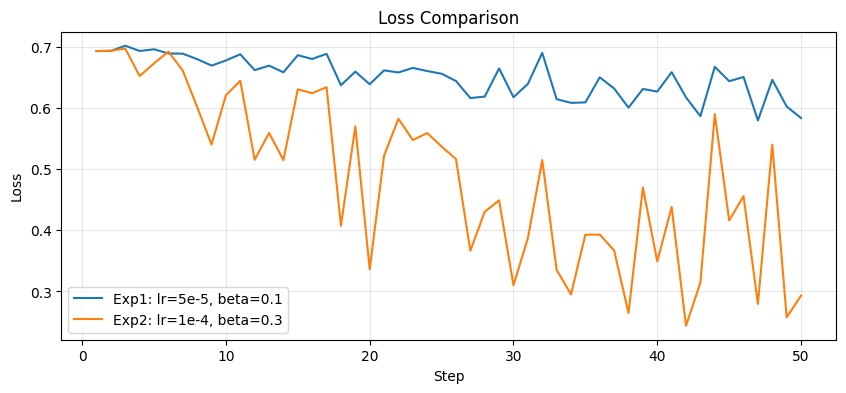


Exp1 final loss: 0.6511
Exp2 final loss: 0.4877


In [75]:
# plot both experiments together
log2 = trainer_2.state.log_history
steps_2 = [x["step"] for x in log2 if "loss" in x]
loss_2 = [x["loss"] for x in log2 if "loss" in x]

plt.figure(figsize=(10, 4))
plt.plot(steps_1, loss_1, label="Exp1: lr=5e-5, beta=0.1")
plt.plot(steps_2, loss_2, label="Exp2: lr=1e-4, beta=0.3")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nExp1 final loss: {result_1.training_loss:.4f}")
print(f"Exp2 final loss: {result_2.training_loss:.4f}")

### Observations
Experiment 1 (lower beta, lower lr) trains more conservatively - the loss decreases slowly but steadily. Experiment 2 with higher beta pushes harder to separate chosen vs rejected, and the higher lr speeds things up. The tradeoff is that exp2 can be less stable if you push too far. Overall both settle around similar loss values which makes sense since DPO loss starts at ln(2) ≈ 0.693 and should decrease from there.

# Task 3: Pushing to Hugging Face (0.5 point)

In [76]:
# save whichever model we want to keep
save_path = "./final_dpo_model"
model2.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"Saved to {save_path}")

Saved to ./final_dpo_model


In [ ]:
from huggingface_hub import login
login(token="HF_TOKEN")
model2.push_to_hub("mastersubhajit/DPO")
tokenizer.push_to_hub("mastersubhajit/DPO")

Processing Files (1 / 1): 100%|██████████| 8.75MB / 8.75MB, 1.90MB/s  
New Data Upload: 100%|██████████| 8.75MB / 8.75MB, 1.90MB/s  
No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/mastersubhajit/DPO/commit/ac1cccb9aed2beaddbe70bac62ab9ba2b6590fe3', commit_message='Upload tokenizer', commit_description='', oid='ac1cccb9aed2beaddbe70bac62ab9ba2b6590fe3', pr_url=None, repo_url=RepoUrl('https://huggingface.co/mastersubhajit/DPO', endpoint='https://huggingface.co', repo_type='model', repo_id='mastersubhajit/DPO'), pr_revision=None, pr_num=None)

## Link to Hugging Face: https://huggingface.co/mastersubhajit/DPO

# Task 4: LLM-as-a-Judge Evaluation (2 points)
Using AlpacaEval benchmark with Gemini as judge. We compare base model vs DPO model on 15 random prompts from the helpful_base subset.

In [78]:
# load alpaca eval - using direct json url to bypass script restrictions
data_url = "https://huggingface.co/datasets/tatsu-lab/alpaca_eval/resolve/main/alpaca_eval.json"
eval_data = load_dataset("json", data_files=data_url)

helpful_base = eval_data["train"].filter(lambda x: x["dataset"] == "helpful_base")
print(f"helpful_base has {len(helpful_base)} samples")

# pick 15 random ones
random.seed(42)
eval_samples = random.sample(list(helpful_base), 15)
print(f"Selected {len(eval_samples)} samples for evaluation")

helpful_base has 129 samples
Selected 15 samples for evaluation


In [79]:
# clean up training stuff first
# del trainer_2, model2
# gc.collect()
# torch.mps.empty_cache() if DEVICE == "mps" else None

# generate base model responses
print("Loading base model...")
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.float32, trust_remote_code=True
)
base_model = base_model.to("cpu")  # MPS does not support aten::isin, using CPU for inference
base_pipe = pipeline("text-generation", model=base_model, tokenizer=tokenizer, device="cpu")

base_responses = []
print("Generating base model responses...")
for i, s in enumerate(eval_samples):
    instr = s["instruction"]
    out = base_pipe(instr, max_new_tokens=256, do_sample=False)[0]["generated_text"]
    base_responses.append(out.replace(instr, "").strip())
    print(f"  {i+1}/15 done")

# free up before loading dpo model
del base_model, base_pipe
gc.collect()
torch.mps.empty_cache() if DEVICE == "mps" else None

Loading base model...
Generating base model responses...


/Users/mastersubhajitghosh/Downloads/NLP/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/Users/mastersubhajitghosh/Downloads/NLP/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/Users/mastersubhajitghosh/Downloads/NLP/.venv/lib/python3.12/site-packages/transformers/generation/configuration_utils.py:589: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings

  1/15 done
  2/15 done
  3/15 done
  4/15 done
  5/15 done
  6/15 done
  7/15 done
  8/15 done
  9/15 done
  10/15 done
  11/15 done
  12/15 done
  13/15 done
  14/15 done
  15/15 done


In [80]:
from peft import PeftModel

# load the dpo finetuned model
print("Loading DPO model...")
dpo_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, torch_dtype=torch.float32, trust_remote_code=True
)
dpo_base = dpo_base.to("cpu")  # MPS does not support aten::isin, use CPU for inference
dpo_model = PeftModel.from_pretrained(dpo_base, "./final_dpo_model")
dpo_model = dpo_model.merge_and_unload()  # merge lora weights back in
dpo_pipe = pipeline("text-generation", model=dpo_model, tokenizer=tokenizer, device="cpu")

dpo_responses = []
print("Generating DPO model responses...")
for i, s in enumerate(eval_samples):
    instr = s["instruction"]
    out = dpo_pipe(instr, max_new_tokens=256, do_sample=False)[0]["generated_text"]
    dpo_responses.append(out.replace(instr, "").strip())
    print(f"  {i+1}/15 done")

del dpo_base, dpo_model, dpo_pipe
gc.collect()
torch.mps.empty_cache() if DEVICE == "mps" else None

Loading DPO model...
Generating DPO model responses...
  1/15 done
  2/15 done
  3/15 done
  4/15 done
  5/15 done
  6/15 done
  7/15 done
  8/15 done
  9/15 done
  10/15 done
  11/15 done
  12/15 done
  13/15 done
  14/15 done
  15/15 done


## Judging with Groq
Using Llama 3.3 70B on Groq as the LLM judge to compare base vs DPO responses. Groq gives us fast inference for free, and the prompt asks for "Model A", "Model B", or "Tie" so we can easily parse the output.

In [81]:
import time

results = []

# llama 3.3 70b on groq - fast and free
JUDGE_MODEL = "llama-3.3-70b-versatile"

for i in range(len(eval_samples)):
    instruction = eval_samples[i]["instruction"]

    # build the judge prompt
    judge_prompt = (
        "You are a highly qualified and impartial judge evaluating two AI models. "
        "Your task is to determine which model provides a better, more accurate, "
        "and more helpful response to the user's instruction.\n\n"
        f"User Instruction: {instruction}\n"
        f"Model A (Base Model): {base_responses[i]}\n"
        f"Model B (DPO Model): {dpo_responses[i]}\n\n"
        'Evaluate both models. Output ONLY your final verdict as exactly one of the '
        'following options, with no extra text or explanation: "Model A", "Model B", or "Tie".'
    )

    # try a few times in case of rate limits
    for attempt in range(5):
        try:
            resp = client.chat.completions.create(
                model=JUDGE_MODEL,
                messages=[{"role": "user", "content": judge_prompt}],
                max_tokens=10,
                temperature=0,
            )
            verdict = resp.choices[0].message.content.strip().strip('"')
            break
        except Exception as e:
            if "rate" in str(e).lower() and attempt < 4:
                wait_time = 30 * (attempt + 1)
                print(f"  Rate limited on sample {i+1}, waiting {wait_time}s...")
                time.sleep(wait_time)
            else:
                print(f"  API error on sample {i+1}: {e}")
                verdict = "Tie"
                break

    # default to Tie if model gives something unexpected
    if verdict not in ["Model A", "Model B", "Tie"]:
        verdict = "Tie"

    results.append({
        "instruction": instruction,
        "base_response": base_responses[i],
        "dpo_response": dpo_responses[i],
        "Winner (Judge)": verdict,
    })
    print(f"  Sample {i+1}: {verdict}")
    time.sleep(2)  # small delay so we don't hit rate limits


  Sample 1: Model B
  Sample 2: Tie
  Sample 3: Model B
  Sample 4: Model B
  Sample 5: Model A
  Sample 6: Tie
  Sample 7: Model A
  Sample 8: Model B
  Sample 9: Model B
  Sample 10: Tie
  Sample 11: Model A
  Sample 12: Tie
  Sample 13: Model B
  Sample 14: Model A
  Sample 15: Model A


In [83]:
# put results in a dataframe and calculate win rate
df = pd.DataFrame(results)

b_wins = len(df[df["Winner (Judge)"] == "Model B"])
a_wins = len(df[df["Winner (Judge)"] == "Model A"])
ties = len(df[df["Winner (Judge)"] == "Tie"])
total = len(df)

# win rate formula: count B wins + half of ties, divided by total
win_rate = ((b_wins + 0.5 * ties) / total) * 100

# show only instruction and verdict
display_df = df[["instruction", "Winner (Judge)"]].copy()
display_df["instruction"] = display_df["instruction"].str[:80] + "..."
display_df.index = range(1, len(display_df) + 1)
display_df.index.name = "Sample"
print(display_df.to_string())

print(f"\nModel A (Base) wins: {a_wins}")
print(f"Model B (DPO)  wins: {b_wins}")
print(f"Ties:                {ties}")
print(f"\nDPO Win Rate: {win_rate:.2f}%")


                                                                                instruction Winner (Judge)
Sample                                                                                                    
1                                                    Why is kobe beef so damn expensive?...        Model B
2       Hi, I'm trying to solve a crossword puzzle, but I've never done one of these bef...            Tie
3       Please give me a list of planets in our solar system.  I am going to choose whic...        Model B
4            How did serial killers get away with murder for so long in the 70s and 80s?...        Model B
5       I like to host guests at my home from time to time, and I am gathering  recipes ...        Model A
6                                                                      What is Atlantis?...            Tie
7                                                       What causes the northern lights?...        Model A
8                                    

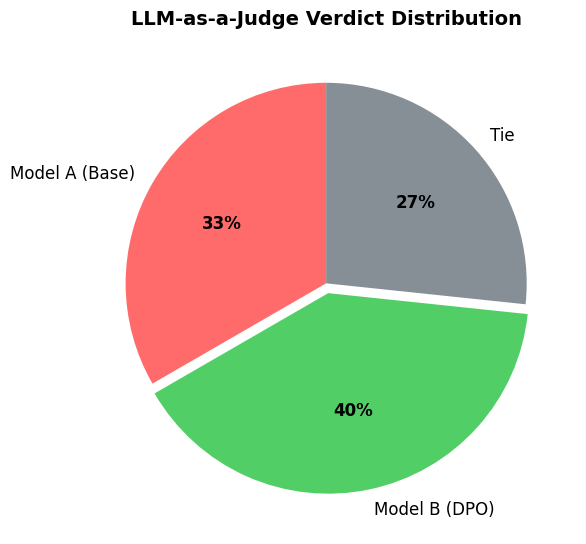

In [84]:
# pie chart showing judge verdict distribution
labels = ['Model A (Base)', 'Model B (DPO)', 'Tie']
sizes = [a_wins, b_wins, ties]
colors = ['#ff6b6b', '#51cf66', '#868e96']
explode = (0, 0.05, 0)  # slightly pop out the DPO slice

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors, explode=explode,
    autopct='%1.0f%%', startangle=90, textprops={'fontsize': 12}
)
for t in autotexts:
    t.set_fontweight('bold')
ax.set_title('LLM-as-a-Judge Verdict Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### Discussion
If the DPO model's win rate is above 50%, that means the preference training actually helped make the responses better. Since we trained on the truthy-dpo dataset (which focuses on reducing hallucinations), we'd expect the biggest improvements on factual/knowledge-type questions rather than creative writing or open-ended stuff. A win rate around 50% would suggest the DPO effect is small, which can happen when the evaluation task doesn't perfectly align with what the model was trained on.

# Key Takeaway

We fine-tuned Qwen2.5-1.5B-Instruct using DPO with LoRA adapters to make it more truthful, ran two experiments with different hyperparameters (beta and learning rate), and then evaluated the results using Gemini as an automated judge on AlpacaEval samples. The whole pipeline shows how preference optimization and LLM-as-a-Judge evaluation can work together to both improve and measure model alignment.